# Machine Learning Foundations - Data Preparation

Intro...

## Task ordering

1. Data Loading
2. Prediction Target and Feature Exploration
3. Visualizing features against target
4. Data Splitting
5. Managing Missing Values
6. Encoding Categorical Variables
7. Feature Selection
8. Feature Scaling
9. Addressing Class Imbalance
10. Training a Logistic Regression Model
11. Model Evaluation

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix,roc_curve, auc, ConfusionMatrixDisplay)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from category_encoders import TargetEncoder

In [2]:
df = pd.read_csv('bank-additional.csv', sep=';')

pd.set_option('display.max_columns', None)
print(df.head())

   age          job  marital          education default  housing     loan  \
0   30  blue-collar  married           basic.9y      no      yes       no   
1   39     services   single        high.school      no       no       no   
2   25     services  married        high.school      no      yes       no   
3   38     services  married           basic.9y      no  unknown  unknown   
4   47       admin.  married  university.degree      no      yes       no   

     contact month day_of_week  duration  campaign  pdays  previous  \
0   cellular   may         fri       487         2    999         0   
1  telephone   may         fri       346         4    999         0   
2  telephone   jun         wed       227         1    999         0   
3  telephone   jun         fri        17         3    999         0   
4   cellular   nov         mon        58         1    999         0   

      poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
0  nonexistent          -1.8        

In [3]:
print('Number of Rows:', df.shape[0])
print('Number of Features:', df.shape[1])
print(df.dtypes)

Number of Rows: 4119
Number of Features: 21
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


## 2. Prediction Target and Feature Exploration

### Description of features

| Feature            | Description                                  | Data Type   |
|--------------------|----------------------------------------------|-------------|
| **age**            | Customer age                                 | Integer     |
| **job**            | Type of job                                  | Categorical |
| **marital**        | Marital status                               | Categorical |
| **education**      | Education level                              | Categorical |
| **default**        | Credit in default                            | Categorical |
| **housing**        | Housing loan                                 | Categorical |
| **loan**           | Personal loan                                | Categorical |
| **contact**        | Contact type                                 | Categorical |
| **month**          | Month of contact                             | Categorical |
| **day_of_week**    | Day of contact                               | Categorical |
| **duration**       | Call duration                                | Integer     |
| **campaign**       | Number of contacts performed during campaign | Integer     |
| **pdays**          | Number of days since last contact            | Integer     |
| **previous**       | Number of previous contacts                  | Integer     |
| **poutcome**       | Outcome of previous campaing                 | Categorical |
| **emp.var.rate**   | Employment variation rate                    | Float       |
| **cons.price.idx** | Consumer price index                         | Float       |
| **cons.conf.idx**  | Consumer confidence index                    | Float       |
| **euribor3m**      | Euribor 3-month rate                         | Float       |
| **nr.employed**    | Number of employees                          | Float       |
| **y**              | Client subscribed to term investment         | Binary      |

Identify column y as target

Subscribed to term deposit after call

Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign.

Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective:
- A. duration
- B. poutcome (previous campaign outcome)

Analyze the distribution of the target variable and comment on potential class imbalance

Change y to numerical for easier understanding and calculations

In [4]:
df['y'] = df['y'].replace({'no': 0, 'yes': 1})
df['y'].astype(int)
print(df['y'].value_counts())

y
0    3668
1     451
Name: count, dtype: int64


In [5]:
print(df['y'].value_counts(normalize=True)*100)

y
0    89.05074
1    10.94926
Name: proportion, dtype: float64


10.95% of call success for the company

This indicates significant class imbalance.

The dataset is heavily skewed toward non-subscription.

Consequences:

A naïve model predicting "no" always would achieve ~89% accuracy. (Baseline)

Accuracy alone is not an appropriate metric.

Precision, recall, F1-score, and ROC-AUC are more informative.

### Numerical feature statistics

In [6]:
print(df.describe())

               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000   103.000000     1.000000   999.000000     0.000000   
50%      38.000000   181.000000     2.000000   999.000000     0.000000   
75%      47.000000   317.000000     3.000000   999.000000     0.000000   
max      88.000000  3643.000000    35.000000   999.000000     6.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx    euribor3m  nr.employed  
count   4119.000000     4119.000000    4119.000000  4119.000000  4119.000000  
mean       0.084972       93.579704     -40.499102     3.621356  5166.481695  
std        1.563114        0.579349       4.594578     1.733591    73.667904  
min       -3.4000

### Unknowns

#### Categorical

In [7]:
unknowns = pd.DataFrame({
    'unknown count': (df == 'unknown').sum(),
    'unknown %': (df == 'unknown').mean() * 100
})

unknowns = unknowns[unknowns['unknown count'] > 0]

unknowns = unknowns.sort_values(
    by='unknown %',
    ascending=False
)

unknowns

,unknown count,unknown %
default,803,19.495023
education,167,4.054382
housing,105,2.549162
loan,105,2.549162
job,39,0.946832
marital,11,0.267055


default has the greatest amount of missing data

poutcome has 85.5% nonexistent but that is intentional

#### Numerical

In [8]:
print(df['pdays'].unique())

[999  12   3   6   5   2  10  11   7   1  18   4  15   0  16   9  19  17
  13  21  14]


in this feature 999, although being a numerical value, represents that the customer has never being contacted

## 3. Visualizing features

### Age

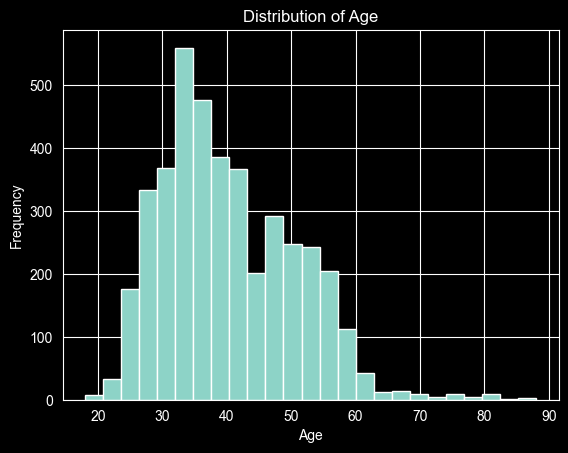

In [9]:
plt.figure()
plt.hist(df['age'], bins=25)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

moderate right skewed

In [10]:
print(df.groupby('y')['age'].mean())
print(f'\nDifference in mean: {- df.groupby('y')['age'].mean()[0] + df.groupby('y')['age'].mean()[1]:.6f}')

y
0    39.895311
1    41.889135
Name: age, dtype: float64

Difference in mean: 1.993824


not relevant, a ~2-year difference is not meaningful for this context, y depends mostly on other features

### Duration

IMPORTANT divide graph by y

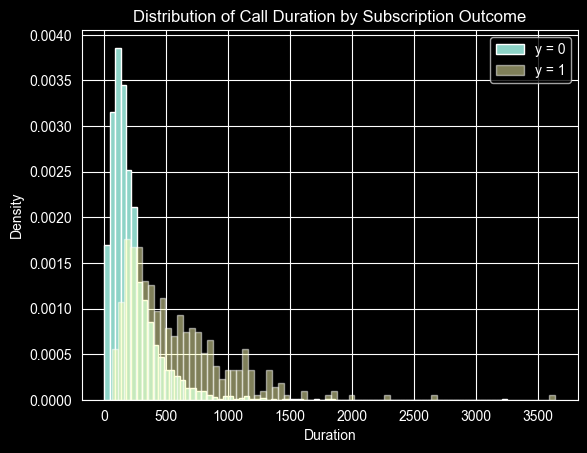

In [11]:
plt.figure()
plt.hist(df[df['y'] == 0]['duration'],
         bins=75,
         alpha=1,
         density=True,
         label='y = 0')
plt.hist(df[df['y'] == 1]['duration'],
         bins=75,
         alpha=0.5,
         density=True,
         label='y = 1')
plt.xlabel('Duration')
plt.ylabel('Density')
plt.title('Distribution of Call Duration by Subscription Outcome')
plt.legend()
plt.show()

strongly right skewed, clear difference between y classes

In [12]:
print(df.groupby('y')['duration'].mean())

y
0    219.40976
1    560.78714
Name: duration, dtype: float64


Seems relevant, but temporal leakage (session 4) do not use, availability at prediction time

### Previous

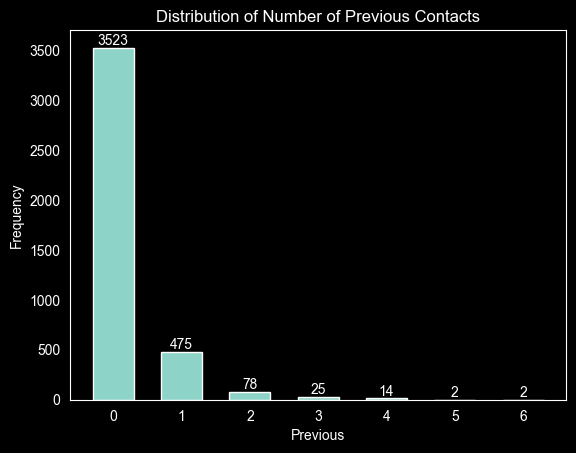

In [13]:
counts = df['previous'].value_counts().sort_index()
plt.figure()
bars = plt.bar(counts.index, counts.values, width=0.6)
plt.xlabel('Previous')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Previous Contacts')
plt.xticks(counts.index)
plt.grid(False)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )
plt.show()

extreme skewness. between yes and no

In [14]:
print(df.groupby('previous')['y'].mean())
print(f'\nAverage positive y without 0: {df.groupby('previous')['y'].mean().drop(0).mean() * 100:.2f}%')
print(f'\nAverage positive y of 0: {df.groupby('previous')['y'].mean()[0] * 100:.2f}%')

previous
0    0.082884
1    0.208421
2    0.410256
3         0.6
4    0.714286
5         1.0
6         0.5
Name: y, dtype: object

Average positive y without 0: 57.22%

Average positive y of 0: 8.29%


From the table of previous to y, the average proportion of true y when previously contacted (no matter how many times) is 57.22%.

While the average proportion of true y when NOT previously contacted is 8.29%

### Pdays

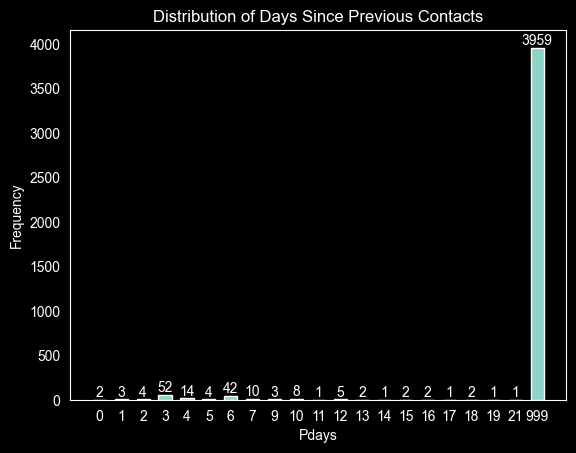

In [15]:
filtered = df[(df['pdays'] <= 25) | (df['pdays'] == 999)]
counts = filtered['pdays'].value_counts().sort_index()
counts.index = counts.index.astype(str)
plt.figure()
bars = plt.bar(range(len(counts)), counts.values, width=0.6)
plt.xlabel('Pdays')
plt.ylabel('Frequency')
plt.title('Distribution of Days Since Previous Contacts')
plt.xticks(range(len(counts)), counts.index)
plt.grid(False)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )
plt.show()

pdays has most records as 999 (never contacted), the other values are between 1 and 21 days since previous contact, which make a small portion of the dataset

In [16]:
print(df.groupby('pdays')['y'].mean())
print(f'\nAverage positive y without 999: {df.groupby('pdays')['y'].mean().drop(999).mean() * 100:.2f}%')
print(f'\nAverage positive y of 999: {df.groupby('pdays')['y'].mean()[999] * 100:.2f}%')

pdays
0           1.0
1           0.0
2          0.25
3          0.75
4      0.357143
5           1.0
6      0.642857
7           0.8
9      0.333333
10         0.75
11          0.0
12          0.6
13          0.0
14          0.0
15          0.5
16          0.0
17          0.0
18          0.5
19          1.0
21          1.0
999    0.088659
Name: y, dtype: object

Average positive y without 999: 47.42%

Average positive y of 999: 8.87%


From the table of pdays to y, the average proportion of true y when previously contacted (no matter amount of days) is 47.42%.

While the average proportion of true y when NOT previously contacted is 8.87%

### Job

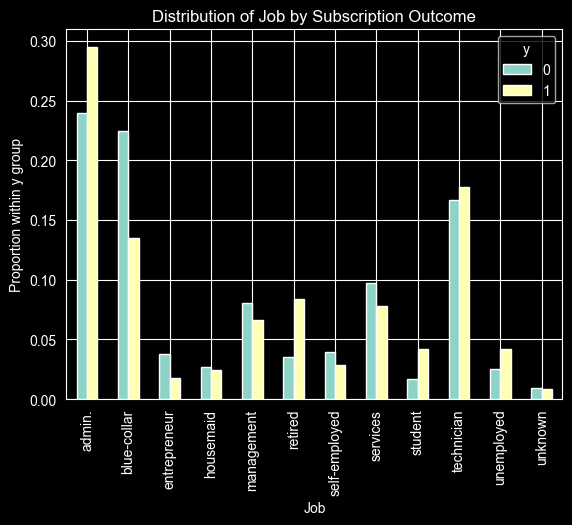

y                     0         1
job                              
admin.         0.239640  0.294900
blue-collar    0.224373  0.135255
entrepreneur   0.038168  0.017738
housemaid      0.026990  0.024390
management     0.080153  0.066519
retired        0.034896  0.084257
self-employed  0.039804  0.028825
services       0.097601  0.077605
student        0.017176  0.042129
technician     0.166576  0.177384
unemployed     0.025082  0.042129
unknown        0.009542  0.008869


In [17]:
pd.crosstab(df['job'], df['y'], normalize='columns').plot(kind='bar')
plt.ylabel("Proportion within y group")
plt.xlabel("Job")
plt.title("Distribution of Job by Subscription Outcome")
plt.show()

print(df.groupby(['job', 'y']).size().unstack().apply(lambda i: i / i.sum(), axis=0))

need stratification, due to class unbalance

### Education

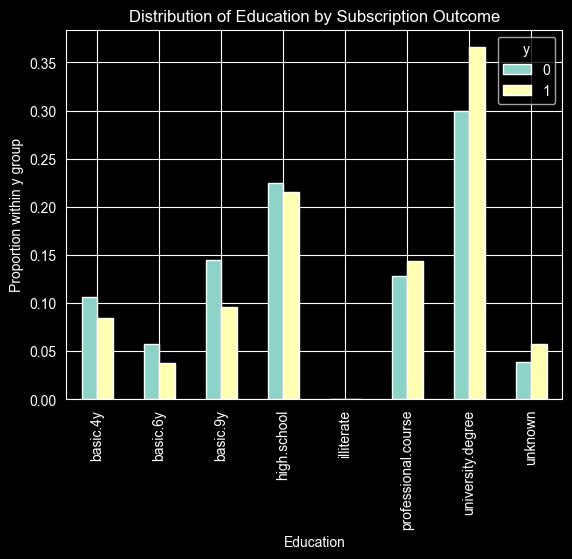

y                           0         1
education                              
basic.4y             0.106598  0.084257
basic.6y             0.057525  0.037694
basic.9y             0.144766  0.095344
high.school          0.224646  0.215078
illiterate           0.000273       NaN
professional.course  0.128135  0.144124
university.degree    0.299618  0.365854
unknown              0.038441  0.057650


In [18]:
pd.crosstab(df['education'], df['y'], normalize='columns').plot(kind='bar')
plt.title("Distribution of Education by Subscription Outcome")
plt.xlabel("Education")
plt.ylabel("Proportion within y group")
plt.show()

print(df.groupby(['education', 'y']).size().unstack().apply(lambda i: i / i.sum(), axis=0))

University Degree
- Higher proportion in y=1 than in y=0
- Suggests higher education is positively associated with subscription

Basic Education Levels (basic.4y, basic.6y, basic.9y)
- Slightly higher proportions in y=0
- Suggests lower education groups are less likely to subscribe

Professional Course
- Slightly higher in y=1

Unknown
- Slightly higher in y=1 (may require investigation)

need stratification, due to class unbalance

## 4. Data Splitting

Split 70/15/15 for train/validation/test

In [19]:
print('Number of Records per Step')
print('Training:', round(df.shape[0] * 0.7))
print('Validation:', round(df.shape[0] * 0.15))
print('Testing:', round(df.shape[0] * 0.15))
print('\nTraining with 60%:', round(df.shape[0] * 0.6))

Number of Records per Step
Training: 2883
Validation: 618
Testing: 618

Training with 60%: 2471


This proportion will allow training to have most of the data, while having sufficient records for validating and testing. I thought at first to do 60/20/20 but with 60% of the data only 2471 records will be used for training, and it seemed low, so I gave it a 10% extra.

In [20]:
y = df['y']
x = df.drop('y', axis=1)

First split into 70% train and 30% for both test and validation

In [21]:
x_train, x_test_val, y_train, y_test_val = train_test_split(
    x, y, test_size=0.3, random_state=4, stratify=y,
)

Second split, the 30% divides 50/50, 15% test and 15% validation

In [22]:
x_test, x_val, y_test, y_val = train_test_split(
    x_test_val, y_test_val, test_size=0.5, random_state=4, stratify=y_test_val,
)

In the splits, stratification was used due to the class unbalance of y, with 89% being 0 and 11% 1, ensuring an equal distribution between sets.

Splitting the data at a laster stage may cause data leakage, specially when computing an average feature value.
- If the average age was calculated and after the data is split, then the average would have information of the test and validation test which leaks the data to the model.
- So it is crucial to split data at the earliest stage before any calculations of modifications are made on the data.

In [23]:
distribution = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
})

distribution

,Original,Train,Validation,Test
y,,,,
0,0.890507,0.890392,0.891586,0.889968
1,0.109493,0.109608,0.108414,0.110032


From the table above it is confirmed that the stratification worked and all sets contain a similar proportion of positive target.

## 5. Managing Missing Values


### Contacts - Pdays and Previous

Both of these features follow a similar structure. As seen from the visualization graphs and ratio of positive y tables, the proportion of contacted vs never contacted is strongly biased to never contacted, in pdays being 999 and in previous being 0.

For pdays:
- Contacted previously (any amount of days) : 47.42% of positive y
- Not recently contacted (999): 8.87% of positive y

For previous:
- Contacted previously (any amount of times) : 57.22% of positive y
- Never contacted (0): 8.29% of positive y

The difference in positive y means that as long as the customer is contacted previously, no matter the amount of days or how many times it is more likely that they subscribe to the term deposit.

Combining all the previously contacted values into one single value will clean the data and still contain the underlying distribution that being contacted increases the likelihood that y is positive. Additionally, the model will work better with a simplified binary representation of pdays and previous, 1 previously contacted and 0 not contacted.

In [24]:
x_train['pdays'] = x_train['pdays'].apply(lambda i: 0 if i == 999 else 1)

x_train['previous'] = x_train['previous'].apply(lambda i: 0 if i == 0 else 1)

print(x_train['pdays'].value_counts())
print('\n', x_train['previous'].value_counts())

pdays
0    2766
1     117
Name: count, dtype: int64

 previous
0    2456
1     427
Name: count, dtype: int64


### Macroeconomic indicators - emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m and nr.employed

These indicators determine the economic situation of customers and can greatly impact their decision on subscribing to term deposit.

Firstly, verify how many values are missing from these features by checking NaN values.

In [25]:
x_train[[
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]].isna().sum()

emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

From the table, there are no missing values for these features. Hence, no further data manipulation is needed.

### Categorical - Job, Marital, Education, Default, Housing and Loan

Personal information features about customers. These features are valuable predictors for the model.

Similarly to the macroeconomic indicators, first verify how many unknown values the dataset has.

In [26]:
print((x_train[[
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan']] == 'unknown').sum()/len(x_train)*100)

job           1.040583
marital       0.277489
education     4.127645
default      19.216094
housing       2.670829
loan          2.670829
dtype: float64


As observed in the table default has the highest amount of unknowns, the others have <5%, which isn't a substantial amount of the data. However, unknown doesn't necessarily represent meaningless. It can also add critical value to the model, due to specific situations that the other categories can't explain.

So, the category unknown will be kept as a separate level as it may carry predictive information and the categorical encoder will handle it appropriately as another category.

## 6. Encoding Categorical Variables


First of all, identifying all the categorical features is necessary.

In [27]:
print(x_train.select_dtypes(include='str').columns.tolist())

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


From this list there are three types of categorical encoding available.
- One-hot encoding
- Mean (target) encoding
- Cyclical encoding

### One-hot Encoding

One-hot encoding creates one different feature column for each category. Each column then has a 0 or 1 if that category is true for that record. This means each category is a nominal variable, has the same level of importance for the data and the model treats them as equal.

As this encoding method creates many columns it enlarges the data and creates more complexity. So, although most categorical features are encoded this way the less features encoded by One-hot encoding the better for model simplicity.

The features for this encoding are:
- Marital
- Default
- Housing
- Loan
- Contact
- Poutcome

In [28]:
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

In [29]:
encoder.fit(x_train[['marital','default','housing','loan','contact','poutcome']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_c

In [30]:
train_encoded = encoder.transform(x_train[['marital','default','housing','loan','contact','poutcome']])
encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(['marital','default','housing','loan','contact','poutcome']),
    index=x_train.index
)
x_train = x_train.drop(columns=['marital','default','housing','loan','contact','poutcome'])
x_train = pd.concat([x_train, encoded_df], axis=1)

In [31]:
print(x_train.shape)
x_train.head()

(2883, 26)


,age,job,education,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,marital_married,marital_single,marital_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,poutcome_success
2845,37,admin.,university.degree,may,mon,442,1,0,0,-1.8,92.893,-46.2,1.244,5099.1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3983,43,admin.,university.degree,aug,tue,161,3,1,1,-2.9,92.201,-31.4,0.838,5076.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4017,38,management,university.degree,aug,wed,157,1,0,0,1.4,93.444,-36.1,4.965,5228.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2466,39,blue-collar,basic.9y,nov,thu,281,2,0,1,-0.1,93.200,-42.0,4.076,5195.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
158,47,technician,unknown,jul,tue,117,2,0,0,1.4,93.918,-42.7,4.961,5228.1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Cyclical Encoding

Cyclical encoding allows repetitive values that loop through time have a value that represent this loop. By using functions such as sine and cosine the cyclical distribution of the categories is described by

The features for this encoding are:
- Month
- Day of week

In [32]:
df['month'].unique().tolist()

['may', 'jun', 'nov', 'sep', 'jul', 'aug', 'mar', 'oct', 'apr', 'dec']

From the list above it is observed that only 10 months are recorded in the entire dataset. However, to preserve calendar integrity and the possibility that campaigns are done during January or February, the encoding will contain the 12 months.

In [33]:
month_mapping = {
    'jan': 0, 'feb': 1, 'mar': 2, 'apr': 3,
    'may': 4, 'jun': 5, 'jul': 6, 'aug': 7,
    'sep': 8, 'oct': 9, 'nov': 10, 'dec': 11
}

x_train['month'] = x_train['month'].map(month_mapping)

x_train['month_sin'] = np.sin(2 * np.pi * x_train['month'] / 12)
x_train['month_cos'] = np.cos(2 * np.pi * x_train['month'] / 12)

x_train = x_train.drop(columns=['month'])

In [34]:
print(x_train[['month_cos', 'month_sin']].head())

      month_cos     month_sin
2845  -0.500000  8.660254e-01
3983  -0.866025 -5.000000e-01
4017  -0.866025 -5.000000e-01
2466   0.500000 -8.660254e-01
158   -1.000000  1.224647e-16


In [35]:
df['day_of_week'].unique().tolist()

['fri', 'wed', 'mon', 'thu', 'tue']

The list shows that only days from monday to friday exist in the data. Differently from months, the calls are done in business days only and there's no meaning on including weekend days. So, the encoding will have a max value of 5 for the 5-week days.

In [36]:
day_mapping = {
    'mon': 0,
    'tue': 1,
    'wed': 2,
    'thu': 3,
    'fri': 4
}

x_train['day_of_week'] = x_train['day_of_week'].map(day_mapping)

x_train['day_sin'] = np.sin(2 * np.pi * x_train['day_of_week'] / 5)
x_train['day_cos'] = np.cos(2 * np.pi * x_train['day_of_week'] / 5)

x_train = x_train.drop('day_of_week', axis=1)

In [37]:
print(x_train[['day_sin', 'day_cos']].head())

       day_sin   day_cos
2845  0.000000  1.000000
3983  0.951057  0.309017
4017  0.587785 -0.809017
2466 -0.587785 -0.809017
158   0.951057  0.309017


### Mean (target) Encoding

Unlike both other encodings, mean (target) encoding can represent a meaningful order of categories that doesn't necessarily follow a linear distribution. It can explain the categories by how meaningful they are in the specific case of each dataset. So, it is useful to explore the strength of each category and give meaningful modeling advantage.

However, it uses the y target to allocate values to the categories, which may result in data leakage and has to be handled carefully. Additionally, if the features being encoded have many categories and some with few records it can lead to overfitting.

The features for this encoding are:
- Job
- Education

Let's now check for overfitting by calculating the number of observations at each category.

In [38]:
x_train['job'].value_counts().sort_values(ascending=False)

job
admin.           680
blue-collar      620
technician       483
services         268
management       244
retired          117
self-employed    113
entrepreneur     110
unemployed        83
housemaid         78
student           57
unknown           30
Name: count, dtype: int64

In [39]:
x_train['education'].value_counts().sort_values(ascending=False)

education
university.degree      873
high.school            650
basic.9y               397
professional.course    371
basic.4y               309
basic.6y               163
unknown                119
illiterate               1
Name: count, dtype: int64

For both features there are a few categories with <100 observation which can start to produce overfitting, specially for illiterate that has only 1 observation.

To solve this issue Cross-Validation must be used on training which allows the model to train with more loops, meaning more data. This will reduce overfitting. In the other hand, it introduces another problem of data leakage at training. The encoding of the data must be done inside the cross-validation at each fold, so the encoder doesn't see the portion of the data being used to train that fold.

A pipeline will be used to allow the Cross-Validation to encode this 2 features at each fold exclusively, finally solving overfitting and leakage problems.

In [40]:
target_encoding_f = ['job', 'education']

target_encoder_pipe = Pipeline(steps=[
    ('target_encoder', TargetEncoder(cols=target_encoding_f, smoothing=10))
])

pipeline defined with one step but might be increased later

In [41]:
pd.crosstab(x_train['education'], y_train, normalize='index')[1]

education
basic.4y               0.097087
basic.6y               0.079755
basic.9y               0.073048
high.school            0.103077
illiterate             0.000000
professional.course    0.129380
university.degree      0.128293
unknown                0.142857
Name: 1, dtype: float64

In [42]:
pd.crosstab(x_train['job'], y_train, normalize='index')[1]

job
admin.           0.141176
blue-collar      0.069355
entrepreneur     0.036364
housemaid        0.128205
management       0.094262
retired          0.230769
self-employed    0.097345
services         0.085821
student          0.263158
technician       0.099379
unemployed       0.168675
unknown          0.066667
Name: 1, dtype: float64

## 7. Feature Selection


Now the features have to be decreased until only the meaningful remain.

The first step to remove features is to check for variance in the numerical features. Excluding the features that have already been encoded - binary and cyclical.

Low variance features mean it doesn't vary between observation and hence carry no predictive information.

A low variance will be measured by being almost 0 (e.g. 0.01).

In [43]:
num_f = ['age', 'duration', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

In [44]:
x_train[num_f].var().sort_values()

cons.price.idx        0.340481
emp.var.rate          2.446255
euribor3m             3.008386
campaign              7.026441
cons.conf.idx        20.828215
age                 105.693024
nr.employed        5471.576978
duration          60780.369497
dtype: float64

From the results none of the features have low variance (near 0). The smallest is cons.price.idx with 0.34 variance which remains sufficiently large to improve prediction power in the model.

No features will be removed based on variance.

Now, moving on to multicollinearity analysis between the features.

In [45]:
corr = x_train[num_f].corr()

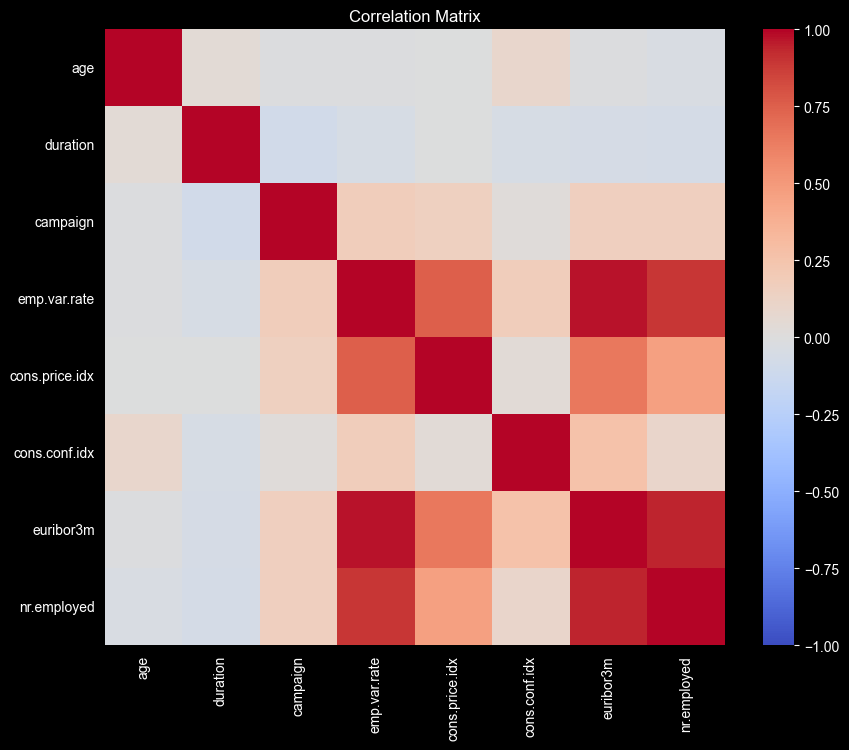

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

The heat map shows several correlations between variables. For example, emp.var.rate is highly related with euribor3m and nr.employed.

To actually calculate all high correlations the threshold will be 0.8. This is the most commonly used threshold to identify multicollinearity risks.

In [47]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.8]

for c in high_corr:
    print(f'{c[0]} & {c[1]}: {c[2]}' )

euribor3m & emp.var.rate: 0.9699287093022902
nr.employed & emp.var.rate: 0.8946409989660307
nr.employed & euribor3m: 0.9425097505913635


There are 3 features interacting with each other: euribor3m, nr.employed, and emp.var.rate.

From these 3 features 2 need to be removed so there are no more correlation issues in the data.

euribor3m will be chosen to stay in the data as it is directly interpretable as the interest rate for a 3-month period. emp.var.rate and nr.employed will be removed due to the strong multicollinearity ( > 0.8)

In [48]:
x_train.drop(['emp.var.rate', 'nr.employed'], axis=1, inplace=True)

Additionally, the feature Duration represents the duration of phone calls, however this value is known only after the call ends and the target y is already known. As the model objective is to predict y before calling the customer, the value of duration will be unknown and unavailable at prediction time. Thus, it has to be removed before training.

In [49]:
x_train.drop('duration', axis=1, inplace=True)

The feature selection has to be done before training so the model trains accurately on information it will have at prediction time, as well as avoiding multicollinearity problems.

If feature selection was done before splitting then the variance test would result in data leakage. The decision on whether a feature has low variance or not would be biased from the full dataset, which is not what the model will see at training.

## 8. Feature Scaling


Features that may need scaling are numerical features that have not been encoded before. So all binary and cyclical features don't need scaling, they are already bounded and have unit variance.

- Job and Education are still categorical at this stage and will be encoded appropriately during Cross-Validation.

Checking for the other possible features:

In [50]:
num = x_train.select_dtypes(include=[np.number]).columns # all numeric

cyc = [c for c in num if c.endswith('_sin') or c.endswith('_cos')] # all cyclical

bn = [c for c in num
    if set(pd.Series(x_train[c].dropna().unique()).astype(float)).issubset({0.0, 1.0})] # all binary

scale = [c for c in num if c not in set(bn + cyc)] # all numeric - cyclical - binary = all to scale

print('Cyclical features:', cyc)
print('\nBinary features:', bn)
print('\nFeatures to scale:', scale)

Cyclical features: ['month_sin', 'month_cos', 'day_sin', 'day_cos']

Binary features: ['pdays', 'previous', 'marital_married', 'marital_single', 'marital_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'poutcome_nonexistent', 'poutcome_success']

Features to scale: ['age', 'campaign', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']


In [51]:
scale_f = ['age', 'campaign', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']

Having the list of feature to do feature scaling, we apply standardization.

Normalization was not chosen because standardization penalizes coefficient magnitude and averages the distribution to have a mean of 0 and standard deviation of 1. Resulting in better numeric stability and performance of the logistic regression model.

The following standardization formula will be used to transform the data:

$$
z_i = \frac{x_i - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

Where:
- $\mu$ is the mean of the feature (training set)
- $\sigma$ is the standard deviation (training set)

Computed on training set to avoid data leakage from the entire dataset.

As this scaling uses the entire training data set to calculate the new distribution it must be included in the pipeline. By including it in the pipeline it is ensured that at each fold none of the data is leaked, maintaining consistency and precision during training.

The pipeline will now be called preprocess as it completes the preprocessing of the data

In [52]:
preprocess = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cols=target_encoding_f, smoothing=10), target_encoding_f),
        ('scaler', StandardScaler(), scale_f)
    ],
    remainder='passthrough')

After scaling the magnitude of features becomes similar, but specially with a mean of 0 that allows understanding and comparability of all features simultaneously. Furthermore, the model can use regularization penalties uniformly across all features. Since logistic regression relies on gradient-based optimization which penalizes likelihood estimation, it is essential to scale for the model to achieve stable interpretation of estimators.

## 9. Addressing Class Imbalance


Class imbalance may be a problem when a class is so small the model considers it negligible and will never predict it.

In [53]:
y_train.value_counts(normalize=True) * 100

y
0    89.039195
1    10.960805
Name: proportion, dtype: float64

In this case positive y has a proportion of 10.96%. Even if it seems small it isn't negligible and therefore the model will try to predict it.

However, it is still small compared to negative y, so we can use a resampling strategy to stabilize the proportion.

For a logistic regression model Random Oversampling is the most robust. It will duplicate the minority class without inventing new points. As it copies exact samples it can cause overfitting, but since cross-validation was planned since before this isn't a high risk issue.

The oversampling has to happen inside each of the cross-validation folds, after the preprocessing of data is done, and before the model trains on the data. Hence, the Random Sampling will be included in the final pipeline.

In [54]:
oversampling = RandomOverSampler(random_state=4)

If oversampling happens before splitting there is potential data leakage risk, as a duplicated observation might be in training and validation sets at the same time.


How class imbalance affects metrics:
- Accuracy: With a ~90% negative y, a model predicting always 0 would achieve 90% accuracy.
- Precision: When there are many negatives, false positives dominate making precision tend to 0.
- Recall: The model will favor the majority class and recall for the minority will drop.

## 10. Training a Logistic Regression Model


The first step to train the model is the finalize the pipeline with correct order:
- Last processing of data
- Using oversampling
- training with logistic regression

In [ ]:
pipe = Pipeline([
    ('preprocess', preprocess),
    ('oversampling', oversampling),
    ('model', LogisticRegression(max_iter=2000, random_state=4))
])

When running there is an issue that y_train has data type object, change to integer so the model is able to interpret it.

In [ ]:
y_train = y_train.astype(int)

Then, it is necessary to state the cross-validation procedure, and other necessary parameters for metric output.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

metrics = {'accuracy': [], 'roc_auc': [], 'f1': [], 'precision': [], 'recall': []}

all_y_true = []
all_y_pred = []

Finally, complete the training with cross-validation, and output useful performance metrics.

In [60]:
for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train), start=1):
    x_tr, x_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipe.fit(x_tr, y_tr)
    y_prob = pipe.predict_proba(x_val)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    roc_auc_val = auc(fpr, tpr)

    # Optimal threshold: closest point to (0,1)
    optimal_idx = np.argmin(np.sqrt(fpr**2 + (1 - tpr)**2))
    optimal_thr = thresholds[optimal_idx]

    print(f'Optimal threshold for Fold {fold}: {optimal_thr:.4f}')

    y_pred = (y_prob >= optimal_thr).astype(int)

    all_y_true.extend(y_val.tolist())
    all_y_pred.extend(y_pred.tolist())

    metrics['accuracy'].append(accuracy_score(y_val, y_pred))
    metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))
    metrics['f1'].append(f1_score(y_val, y_pred))
    metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
    metrics['recall'].append(recall_score(y_val, y_pred))

    print(f"Fold {fold} | Acc: {metrics['accuracy'][-1]:.4f} | "
          f"AUC: {metrics['roc_auc'][-1]:.4f} | F1: {metrics['f1'][-1]:.4f} | Recall: {metrics['recall'][-1]:.4f}\n")

Optimal threshold for Fold 1: 0.3754
Fold 1 | Acc: 0.6655 | AUC: 0.7627 | F1: 0.3413 | Recall: 0.7812

Optimal threshold for Fold 2: 0.5687
Fold 2 | Acc: 0.8094 | AUC: 0.7890 | F1: 0.4554 | Recall: 0.7302

Optimal threshold for Fold 3: 0.5097
Fold 3 | Acc: 0.7903 | AUC: 0.7938 | F1: 0.4265 | Recall: 0.7143

Optimal threshold for Fold 4: 0.4793
Fold 4 | Acc: 0.7726 | AUC: 0.7591 | F1: 0.3907 | Recall: 0.6667

Optimal threshold for Fold 5: 0.4143
Fold 5 | Acc: 0.7292 | AUC: 0.7533 | F1: 0.3607 | Recall: 0.6984



## 11. Model Evaluation

In [61]:
print("---- Cross-Validation Summary ----")
for metric, values in metrics.items():
    print(f"{metric.upper():<12} mean={np.mean(values):.4f}  std={np.std(values):.4f}")

---- Cross-Validation Summary ----
ACCURACY     mean=0.7534  std=0.0513
ROC_AUC      mean=0.7716  std=0.0165
F1           mean=0.3949  std=0.0418
PRECISION    mean=0.2745  std=0.0405
RECALL       mean=0.7182  std=0.0379


In [65]:
cm = confusion_matrix(all_y_true, all_y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1'])
print(cm_df)

          Predicted 0  Predicted 1
Actual 0         1945          622
Actual 1           89          227


In [68]:
cm = confusion_matrix(all_y_true, all_y_pred, normalize='true')
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1'])
print(cm_df)

          Predicted 0  Predicted 1
Actual 0     0.757694     0.242306
Actual 1     0.281646     0.718354


AI, for data visualization code

Summary of data manipulation order

1. split data
2. change pdays and previous to binary
3. one hot encoding on - Marital Default Housing Loan Contact Poutcome
4. cyclical encoding on - month day of week
5. mean (target) encoding on - jod education (in pipeline)
6. remove emp.var.rate and nr.employed due to high multicollinearity
7. remove duration due to unavailability at prediction time
8. feature scaling (standardization) on - age campaign cons.price.idx cons.conf.idx euribor3m
9. oversampling of class imbalance (Random Oversampling)
10. Train model with logistic regression through pipeline